In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df    = pd.read_csv("../data/processed/transfers_features.csv")
train = pd.read_csv("../data/processed/train.csv")
test  = pd.read_csv("../data/processed/test.csv")

print(df.shape)
print(df.dtypes)

(6097, 49)
league                         str
season                       int64
window                         str
team_id                      int64
team_name                      str
team_country                   str
dir                            str
player_id                    int64
player_name                    str
player_age                 float64
player_nation                  str
player_pos                     str
counter_team_id              int64
counter_team_name              str
counter_team_country           str
transfer_fee_amnt          float64
market_val_amnt            float64
is_free                       bool
is_loan                       bool
is_loan_end                   bool
is_retired                    bool
transfer_id                  int64
log_transfer_fee           float64
log_market_value           float64
age_sq                     float64
buying_club_median_fee     float64
log_buying_club_median     float64
sub_position                   str
foot     

In [39]:
# One last filter to remove outliers and bad data points
before = len(df)
df = df[df["transfer_fee_amnt"] >= 100_000]
df = df[df["transfer_fee_amnt"] >= 0.05 * df["market_val_amnt"]]
after = len(df)
print(f"removed {before - after} rows ({(before-after)/before:.1%})")

removed 135 rows (2.2%)


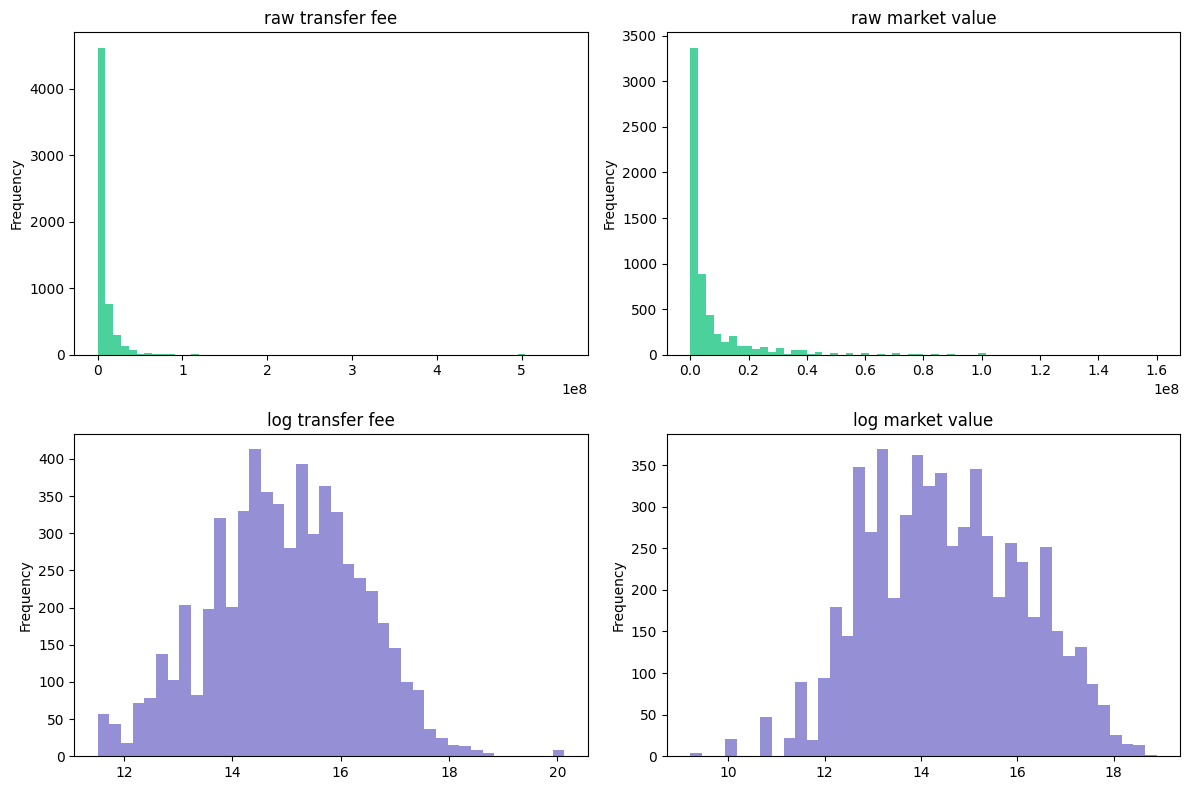

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df["transfer_fee_amnt"].plot(kind="hist", bins=60, ax=axes[0,0],
    title="raw transfer fee", color="#4BD29C")
df["market_val_amnt"].plot(kind="hist", bins=60, ax=axes[0,1],
    title="raw market value", color="#4BD29C")
df["log_transfer_fee"].plot(kind="hist", bins=40, ax=axes[1,0],
    title="log transfer fee", color="#958FD5")
df["log_market_value"].plot(kind="hist", bins=40, ax=axes[1,1],
    title="log market value", color="#958FD5")

plt.tight_layout()
plt.show()

### Exploratory Data Analysis:

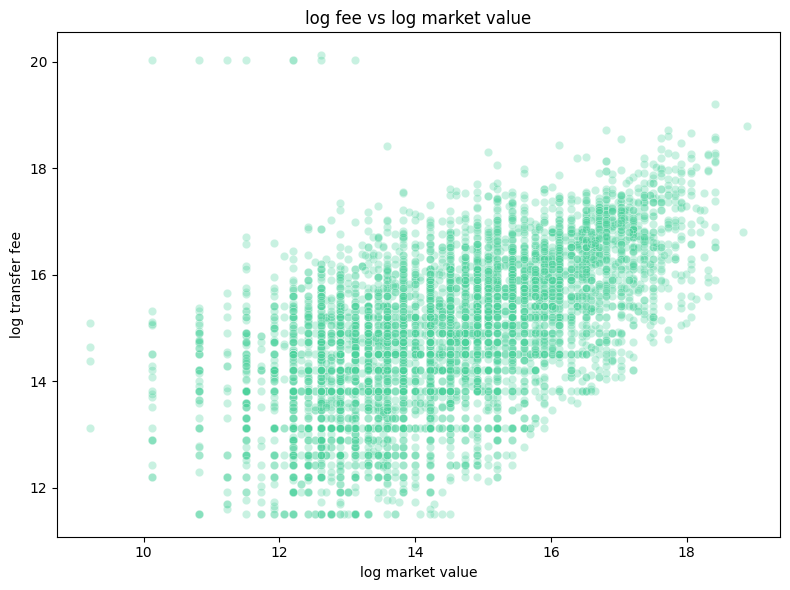

pearson r: 0.587


In [41]:
# Fee vs market value

plt.figure(figsize=(8, 6))
sns.scatterplot(x="log_market_value", y="log_transfer_fee",
                data=df, alpha=0.3, color="#4BD29C")
plt.xlabel("log market value")
plt.ylabel("log transfer fee")
plt.title("log fee vs log market value")
plt.tight_layout()
plt.show()

corr = df[["log_market_value", "log_transfer_fee"]].corr().iloc[0,1]
print(f"pearson r: {corr:.3f}")

In [42]:
print(df["log_transfer_fee"].describe().round(2))
print(df["transfer_fee_amnt"].min())

count    5962.00
mean       14.97
std         1.36
min        11.51
25%        14.08
50%        14.99
75%        15.91
max        20.13
Name: log_transfer_fee, dtype: float64
100000.0


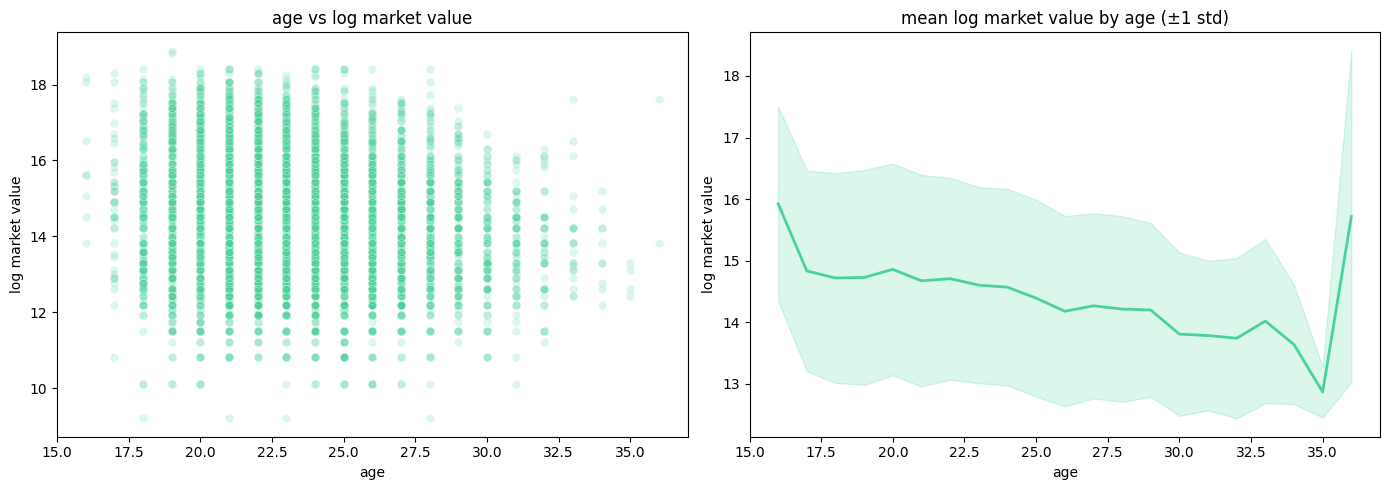

In [43]:
# Age Curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter
sns.scatterplot(x="player_age", y="log_market_value",
                data=df, alpha=0.2, color="#4BD29C", ax=axes[0])
axes[0].set_title("age vs log market value")
axes[0].set_xlabel("age")
axes[0].set_ylabel("log market value")

# mean value by age
age_mean = df.groupby("player_age")["log_market_value"].mean()
age_std  = df.groupby("player_age")["log_market_value"].std()

axes[1].plot(age_mean.index, age_mean.values, color="#4BD29C", linewidth=2)
axes[1].fill_between(age_mean.index,
                     age_mean - age_std,
                     age_mean + age_std,
                     alpha=0.2, color="#4BD29C")
axes[1].set_title("mean log market value by age (±1 std)")
axes[1].set_xlabel("age")
axes[1].set_ylabel("log market value")

plt.tight_layout()
plt.show()

In [44]:
print(df.groupby("player_age")["player_id"].count().sort_index())

player_age
16.0      8
17.0     43
18.0    228
19.0    408
20.0    524
21.0    655
22.0    687
23.0    731
24.0    665
25.0    555
26.0    448
27.0    334
28.0    244
29.0    161
30.0    111
31.0     76
32.0     46
33.0     22
34.0     10
35.0      4
36.0      2
Name: player_id, dtype: int64


In [45]:
df = df[(df["player_age"] >= 17) & (df["player_age"] <= 34)]

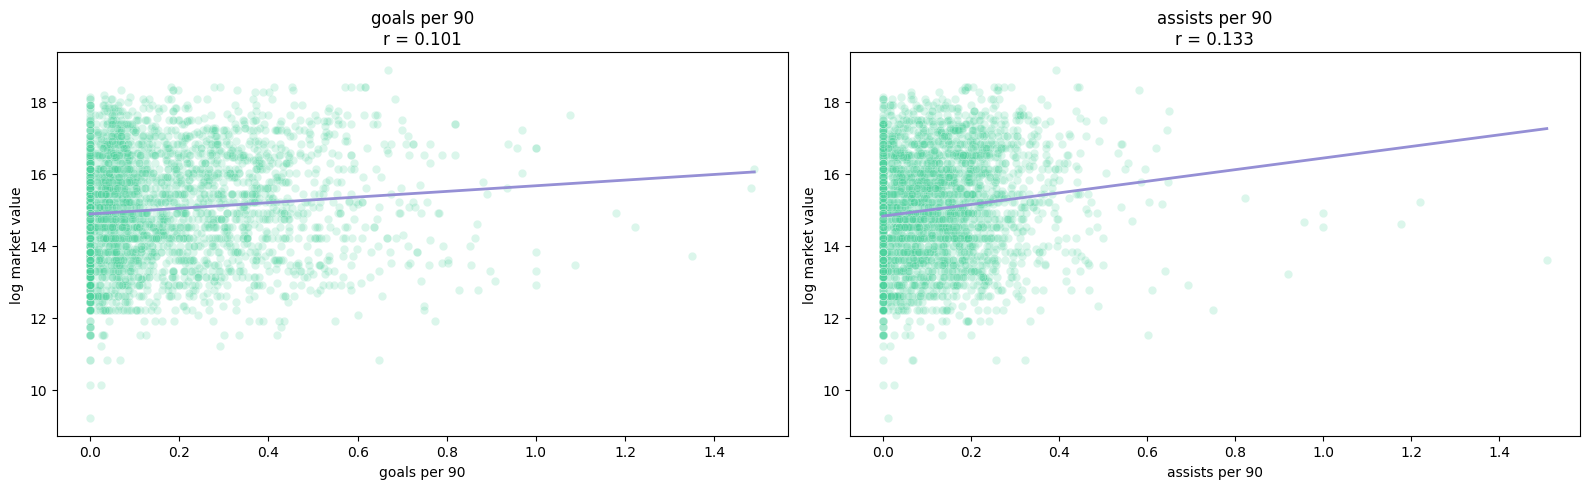

In [47]:
# Performance features
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, label in zip(axes,
    ["goals_per_90", "assists_per_90"],
    ["goals per 90", "assists per 90"]):

    # only plot rows with actual history, zeros would swamp the plot
    subset = df[df["has_appearance_history"] == 1]
    sns.scatterplot(x=col, y="log_market_value",
                    data=subset, alpha=0.2, color="#4BD29C", ax=ax)
    
    # add regression line
    m, b = np.polyfit(subset[col], subset["log_market_value"], 1)
    x_range = np.linspace(subset[col].min(), subset[col].max(), 100)
    ax.plot(x_range, m * x_range + b, color="#958FD5", linewidth=2)
    
    corr = subset[[col, "log_market_value"]].corr().iloc[0,1]
    ax.set_title(f"{label}\nr = {corr:.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel("log market value")

plt.tight_layout()
plt.show()

- In general we observe a weak correlation between G/A per 90 and Market Value. This is likely due to performance stats carrying the real information, but only within position, not across the full dataset.
- Essentially 0 correlation in raw minutes per game and market value (exclude)

- Likely because Transfermarkt valuations already incorporate observable performance metric, retained for model 1 for nonlinear interactions, not expected to be primary drivers of predictive performance

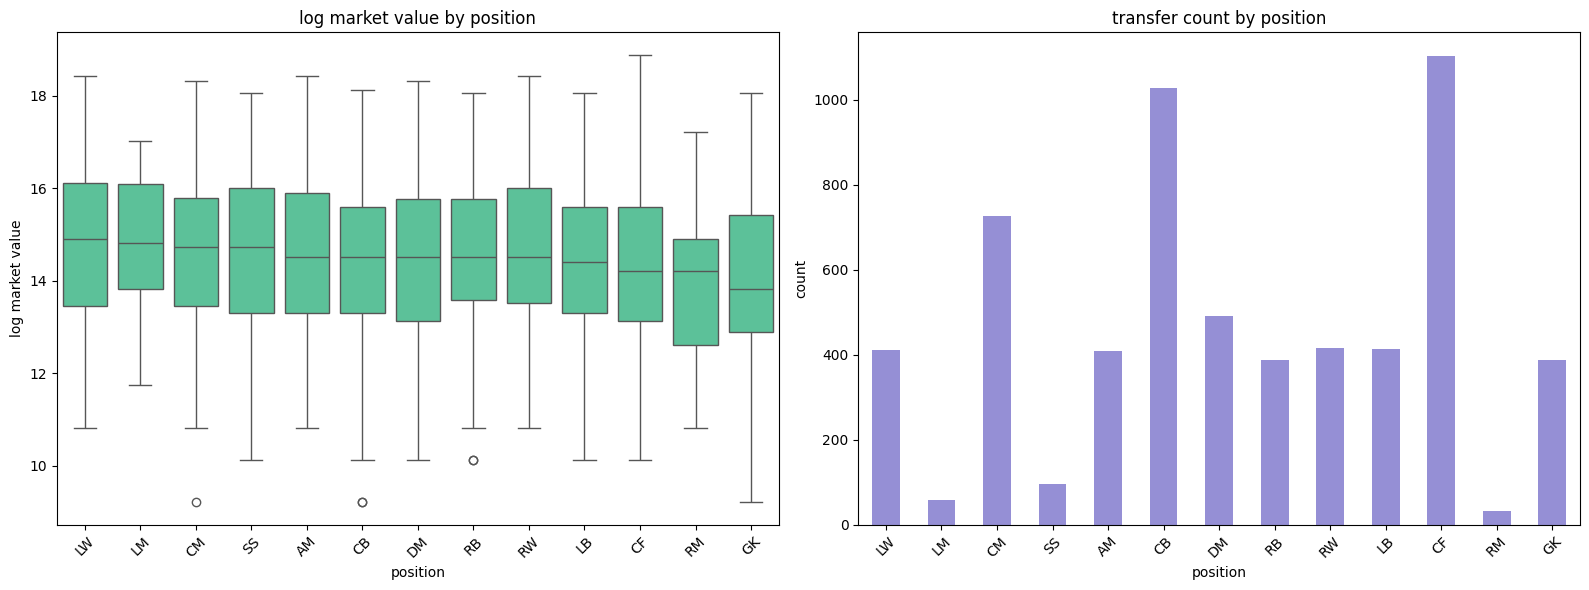

In [ ]:
# Position analysis:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# median log market value by position
pos_order = df.groupby("player_pos")["log_market_value"].median().sort_values(ascending=False).index

sns.boxplot(x="player_pos", y="log_market_value",
            data=df, order=pos_order,
            color="#4BD29C", ax=axes[0])
axes[0].set_title("log market value by position")
axes[0].set_xlabel("position")
axes[0].set_ylabel("log market value")
axes[0].tick_params(axis='x', rotation=45)

# count by position
df["player_pos"].value_counts()[pos_order].plot(
    kind="bar", color="#958FD5", ax=axes[1])
axes[1].set_title("transfer count by position")
axes[1].set_xlabel("position")
axes[1].set_ylabel("count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

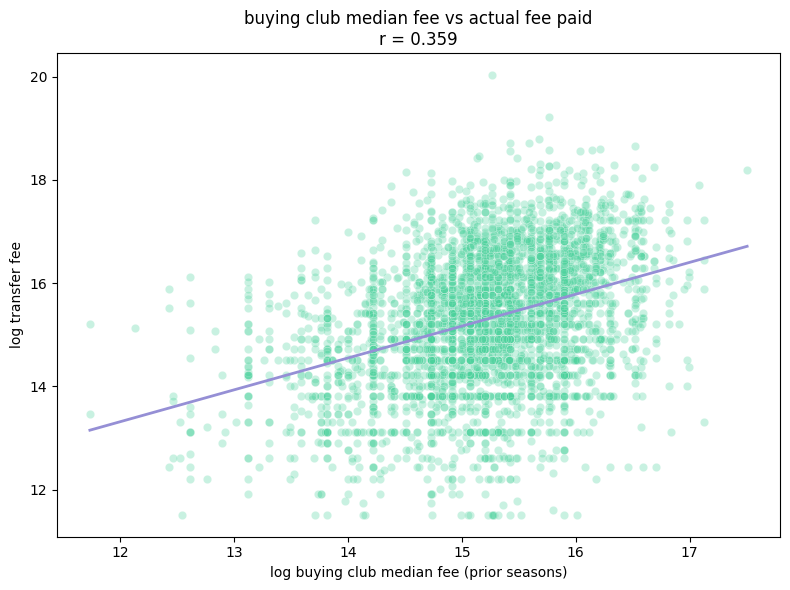

In [ ]:
# Buying club median fee
subset = df[df["has_buying_club_history"] == 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x="log_buying_club_median", y="log_transfer_fee",
                data=subset, alpha=0.3, color="#4BD29C")

m, b = np.polyfit(subset["log_buying_club_median"],
                  subset["log_transfer_fee"], 1)
x_range = np.linspace(subset["log_buying_club_median"].min(),
                      subset["log_buying_club_median"].max(), 100)
plt.plot(x_range, m * x_range + b, color="#958FD5", linewidth=2)

corr = subset[["log_buying_club_median", "log_transfer_fee"]].corr().iloc[0,1]
plt.title(f"buying club median fee vs actual fee paid\nr = {corr:.3f}")
plt.xlabel("log buying club median fee (prior seasons)")
plt.ylabel("log transfer fee")
plt.tight_layout()
plt.show()

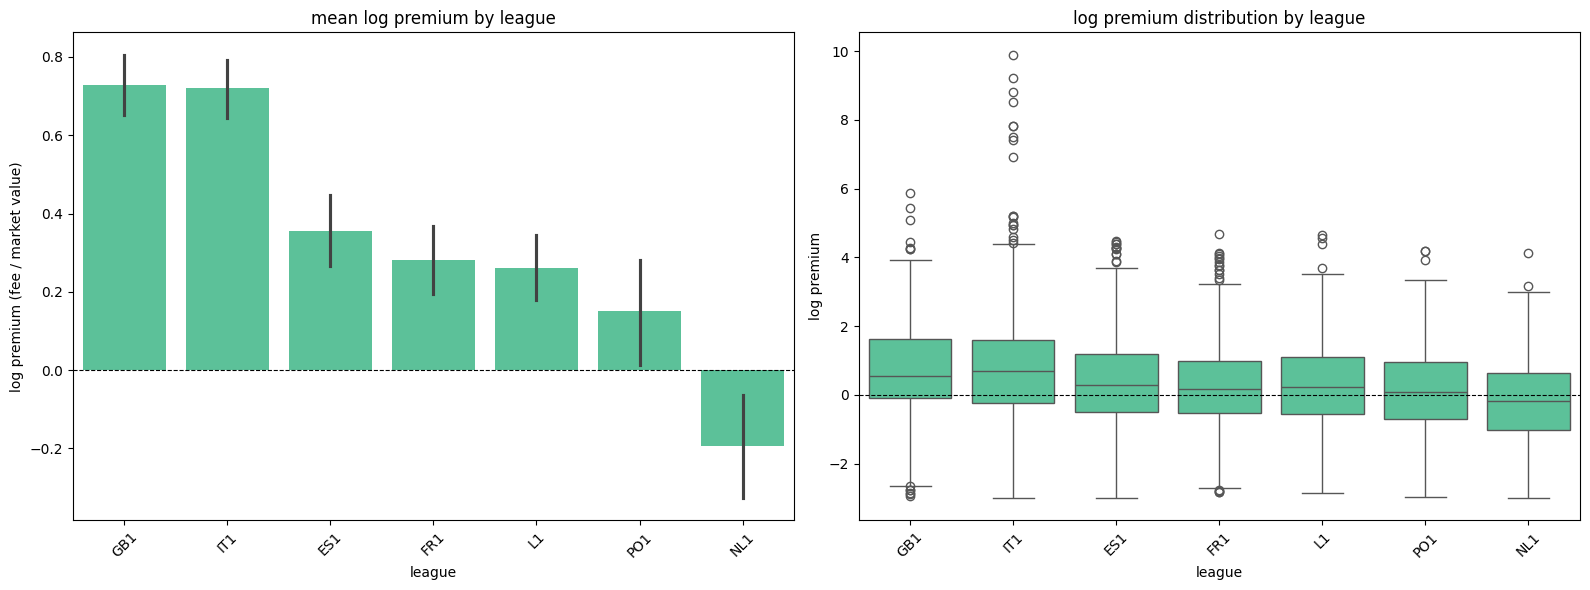

         mean    std  count
league                     
ES1     0.356  1.300    798
FR1     0.281  1.235    825
GB1     0.728  1.334   1123
IT1     0.721  1.517   1546
L1      0.260  1.271    915
NL1    -0.193  1.256    368
PO1     0.151  1.360    387


In [ ]:
# League analysis:
df["log_premium"] = df["log_transfer_fee"] - df["log_market_value"]

league_order = df.groupby("league")["log_premium"].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x="league", y="log_premium",
            data=df, order=league_order,
            color="#4BD29C", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("mean log premium by league")
axes[0].set_xlabel("league")
axes[0].set_ylabel("log premium (fee / market value)")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x="league", y="log_premium",
            data=df, order=league_order,
            color="#4BD29C", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("log premium distribution by league")
axes[1].set_xlabel("league")
axes[1].set_ylabel("log premium")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(df.groupby("league")["log_premium"].agg(["mean","std","count"]).round(3))

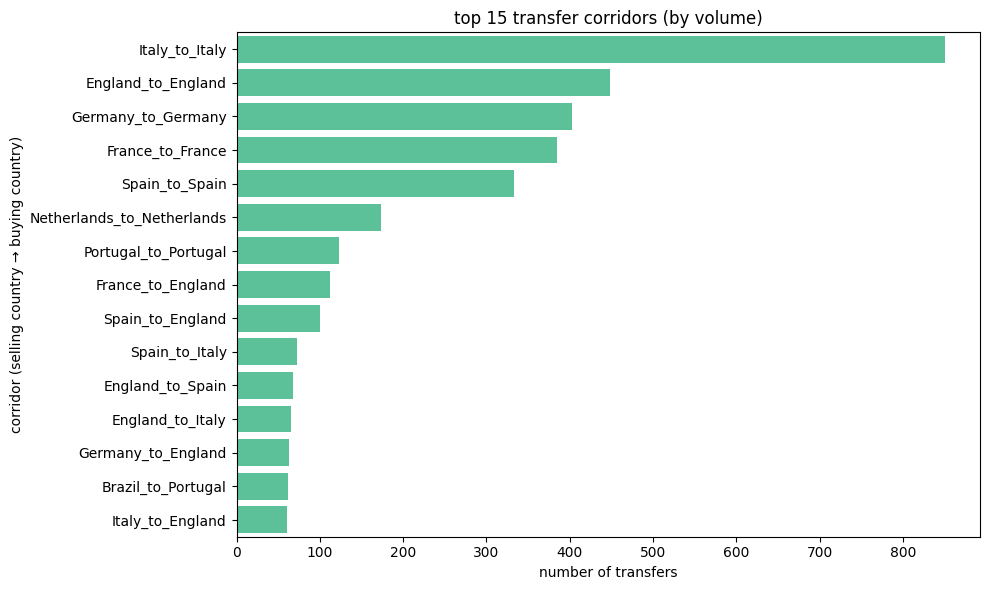

                             mean    std  count
league_pair                                    
Italy_to_Italy              0.962  1.576    850
Spain_to_England            0.773  1.392    100
England_to_England          0.725  1.364    448
France_to_England           0.706  1.305    112
Spain_to_Italy              0.659  1.457     72
France_to_France            0.259  1.314    385
Spain_to_Spain              0.228  1.250    333
Germany_to_Germany          0.223  1.237    403
Portugal_to_Portugal       -0.264  1.213    123
Netherlands_to_Netherlands -0.333  1.216    174


In [ ]:
# League Corridors:
corridor_counts = df["league_pair"].value_counts().head(15).reset_index()
corridor_counts.columns = ["corridor", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(x="count", y="corridor",
            data=corridor_counts, color="#4BD29C")
plt.title("top 15 transfer corridors (by volume)")
plt.xlabel("number of transfers")
plt.ylabel("corridor (selling country → buying country)")
plt.tight_layout()
plt.show()

# also show mean premium per corridor (top 10 by volume)
top_corridors = corridor_counts["corridor"].head(10).tolist()
corridor_premium = df[df["league_pair"].isin(top_corridors)].groupby(
    "league_pair")["log_premium"].agg(["mean","std","count"]).round(3)
print(corridor_premium.sort_values("mean", ascending=False))

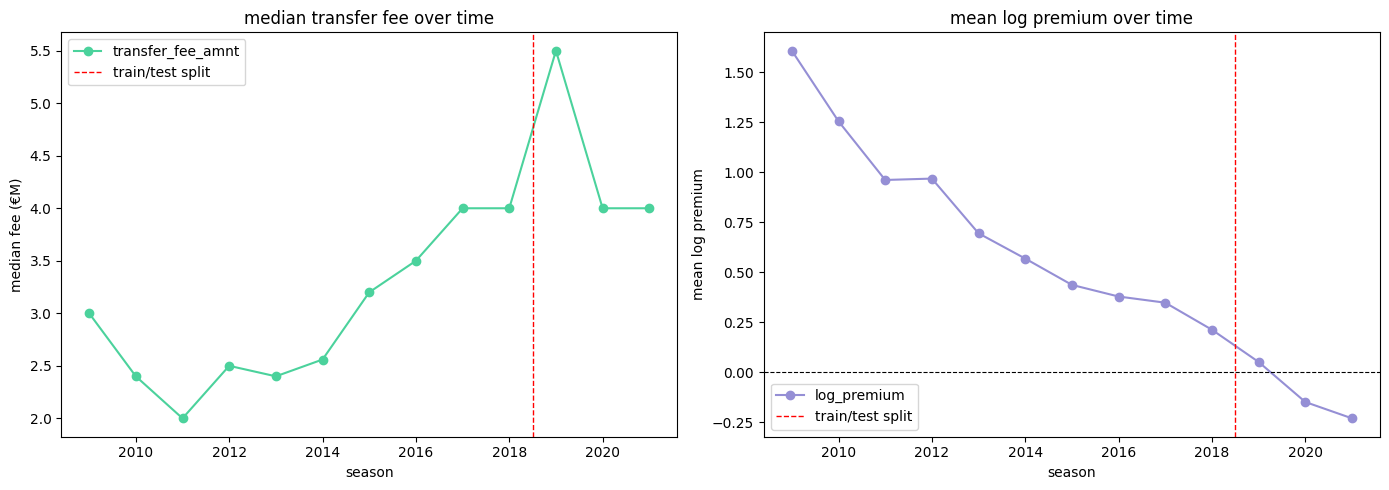

In [ ]:
# Temporal trends:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# median fee over time
median_by_season = df.groupby("season")["transfer_fee_amnt"].median() / 1_000_000
median_by_season.plot(kind="line", ax=axes[0],
                      color="#4BD29C", marker="o")
axes[0].set_title("median transfer fee over time")
axes[0].set_xlabel("season")
axes[0].set_ylabel("median fee (€M)")
axes[0].axvline(2018.5, color="red", linestyle="--", linewidth=1, label="train/test split")
axes[0].legend()

# mean log premium over time
premium_by_season = df.groupby("season")["log_premium"].mean()
premium_by_season.plot(kind="line", ax=axes[1],
                       color="#958FD5", marker="o")
axes[1].set_title("mean log premium over time")
axes[1].set_xlabel("season")
axes[1].set_ylabel("mean log premium")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].axvline(2018.5, color="red", linestyle="--", linewidth=1, label="train/test split")
axes[1].legend()

plt.tight_layout()
plt.show()